# Assignment #2 - Convolutional Neural Networks

<font color="red"> <b> Due: Mar 6 (Friday) 11:00 pm </b> </font>

<font color="blue"> Abeoseh Flemister </font>

# Introduction

[General introduction of this writing assignment] Describe the objective of this assignment. You can briefly state how you accompilsh it.

In [ ]:
from keras.applications.resnet50 import ResNet50
# import torchvision.transforms as transforms
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, datasets
print("TF version:", tf.__version__)

import tensorflow_datasets as tfds
import tensorflow as tf

import matplotlib.pyplot as plt
import numpy as np

import keras_tuner

import os
os.environ['SM_FRAMEWORK'] = 'tf.keras'

import segmentation_models as sm 

# import tensorflow_addons as tfa

import pandas as pd

import glob

TF version: 2.20.0


# Data

**Introduce** your image data and **visualize** them. Describe your observations about the data.
Please check some of visualizations in the labs (you can explore more for others).

**Please do not use the data we practiced in the lab. Also, make sure to play with about 1000 samples. You can scale down or up the image if need.**


In [4]:
# create a new generator
imagegen = keras.preprocessing.image.ImageDataGenerator()


# load train data
train = imagegen.flow_from_directory("./card_archive/train/", class_mode="categorical", shuffle=True, batch_size=128, target_size=(224, 224))
# load val data
val = imagegen.flow_from_directory("./card_archive/valid/", class_mode="categorical", shuffle=True, batch_size=128, target_size=(224, 224))
# load the test data
test = imagegen.flow_from_directory("./card_archive/test/", class_mode="categorical", shuffle=True, batch_size=128, target_size=(224, 224))


classes = pd.read_csv("./card_archive/cards.csv").loc[:,["class index", "labels"]].drop_duplicates(subset=["class index", "labels"])
classes = {classes.iloc[i,0]: classes.iloc[i,1] for i in range(classes.shape[0])}

Found 7624 images belonging to 53 classes.
Found 265 images belonging to 53 classes.
Found 265 images belonging to 53 classes.


As we can see the cards are highly varied which means the model will not overfit to the image on the inside of the card.

In [46]:
def show_img(x, title="", bot=""): ## bot is bottom
    plt.imshow(x)
    plt.xticks([])
    plt.yticks([])
    plt.title(title)
    plt.xlabel(bot)


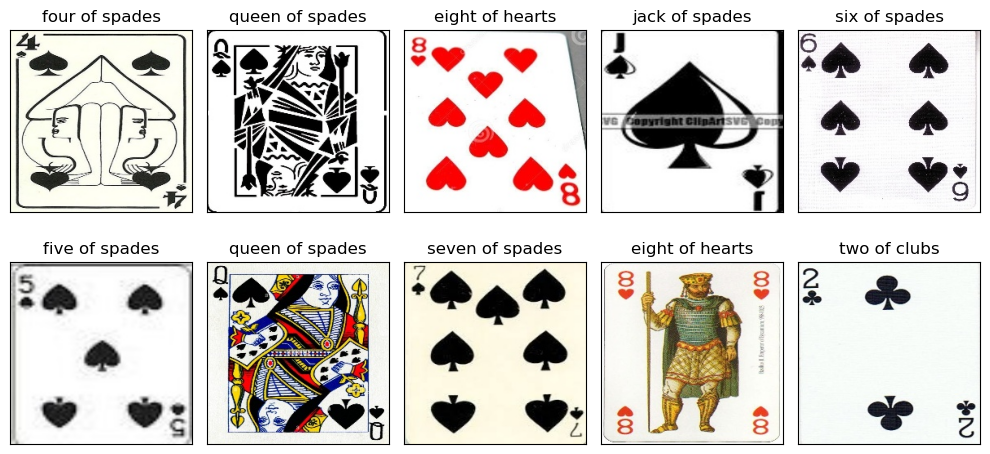

In [156]:
images, labels = next(train)

plt.figure(figsize = (10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    show_img(images[i]/255.0, list(classes.values())[ (labels[i] == 1).nonzero()[0].item() ])

plt.tight_layout()

I am multi-hot encoding the labels since each image contains multiple labels. 

The original image size is 500, 333, 3 but I am resizing it to be 128, 128, 3. Since the images contain multiple classes with some of them (such as bottles) being small, I don't want to make the images too pixelated since it would make it hard to classify the images. 

The test dataset does not have publically available class labels. This makes evaluation of the test sets preformance infeasible so I will use the validation dataset as the validation and test dataset.

## 

# ResNet-50

To save your computation, we leverage pretrained models. Using transfer learning, we only finetune ResNet-50 for image classification and image segmentation.

Summarize the ResNet-50 model here before start loading it, and then implement the codes that load the base model.


<font color="red"> NOTE: We do not consider comments in the code cell as a proper writing. Make sure explain in a Markdown cell not regardless the comment in the code cell. </font>


# Helper Functions

These are the functions that all parts (classification without augmentation, classification with augmentation, and segmentation) will use. 

In [5]:
def plot_learning(history, title, label: str, metric, val_metric):
    """
      title: graph name
      label: y-axis label
      metric: metric you're plotting
      val_metric: validation metric you're plotting
    """
    plt.plot(history.history[metric], label=metric)
    plt.plot(history.history[val_metric], label=val_metric)
    plt.xlabel('Epoch')
    plt.ylabel(f'{label}')
    plt.title(title)
    plt.legend()
    plt.show()

# Image Classification

Here are checklist items that you should work on:

1. Explain your ResNet-50 based CNN for image classification and implement it.
1. Load your image classification data, and then train the image classifier.
1. Properly search hyperparameters to tune the best performing model (report hyperparameter search process, e.g., cross validation).
1. Visualize and evaluate the performance of your image classification.

Place these items under the following Method and Experiment subsections.


## Method

In [6]:
res_base = ResNet50(include_top=False, weights='imagenet', input_shape = (224,224,3))
res_base.trainable = False


In [9]:
class ResPretrained(keras.Model):
    def __init__(self):
        super().__init__()

        # Bias
        bias = tf.Variable(tf.random.normal([3]), trainable=True, name="bias")

        # Single Sequential model
        self.model = keras.Sequential([
            layers.Input(shape=(128,128,3)),
            layers.Lambda(keras.applications.vgg16.preprocess_input),
            layers.Lambda(lambda x: tf.nn.bias_add(x, bias)),
            res_base,
            layers.Flatten(),
            layers.Dense(256),
            layers.Dropout(0.5),
            layers.Dense(20, activation="sigmoid"),
        ])
        self.model.summary()

    # def call(self, inputs):
    #     return self.model(inputs)

ResPretrainedModel = ResPretrained()
ResPretrainedModel.model.compile(loss = "binary_crossentropy", optimizer="rmsprop", metrics=[tf.keras.metrics.BinaryAccuracy(),tf.keras.metrics.Precision(),tf.keras.metrics.Recall()])

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_1 (Lambda)               │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 4, 4, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 20)             │         5,140 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,981,716 (122.00 MB)

 Trainable params: 8,394,004 (32.02 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

On the output layer I am using sigmoid where for each of the 20 classes I am predicting if the image contains that class. 

First I want to do a random search do determine the best hyperparameters for the model. 

I am tuning:
1. the number of units in the hidden dense layer with possible values of 8, 100, 265
2. 

In [8]:
def build_model(hp):
    bias = tf.Variable(tf.random.normal([3]), trainable=True, name="bias")

    model = keras.Sequential([
                layers.Input(shape=(224,224,3)),
                layers.Lambda(keras.applications.vgg16.preprocess_input),
                layers.Lambda(lambda x: tf.nn.bias_add(x, bias)),
                res_base,
                layers.Flatten(),
                layers.Dense(hp.Choice('units', [100, 265, 300])),
                layers.Dropout(hp.Choice('rate', [0.2, 0.5, 0.6])),
                layers.Dense(53, activation="softmax"),
            ])
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-3, 1e-4, 1e-5])

              
    model.compile(optimizer=keras.optimizers.Adam(learning_rate = hp_learning_rate),
                  loss = "categorical_crossentropy", 
                  metrics = ["accuracy"])
    return model

## Experiments

In case I need to reload the model

In [102]:
tuner = keras_tuner.RandomSearch(
    build_model,
    objective=['val_loss', 'val_accuracy'],
    max_trials=5,
    overwrite=False)

tuner.search(train, epochs=10, validation_data=val)

# classify_noaugment = tuner.get_best_models()[0]
trials = list(tuner.oracle.trials.values())
print(f"Found {len(trials)} trials")

trials

Reloading Tuner from .\untitled_project\tuner0.json
Found 5 trials


I scored the models based on the validation loss and accuracy, but I want to pick the best model based on the best validation accuracy so I will use this to do so. 

In [103]:
trials = tuner.oracle.trials.values()
accuracies = {i: list(trials)[i].metrics.get_history("val_accuracy")[-1].value[0] for i in range(len(list(trials))) if i != 3}


accuracies

{0: 0.6792452931404114,
 1: 0.7358490824699402,
 2: 0.7094339728355408,
 4: 0.7169811129570007}

In [38]:
selected_trial = tuner.oracle.trials["1"]
hp = selected_trial.hyperparameters
classify_noaugment = build_model(hp)



In [ ]:

print("best values:", hp.values)


classify_noaugment.summary()


best values: {'units': 265, 'rate': 0.6, 'learning_rate': 0.0001}


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda_2 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lambda_3 (Lambda)               │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 265)            │    26,593,545 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 265)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 53)             │        14,098 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 50,195,355 (191.48 MB)

 Trainable params: 26,607,643 (101.50 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

I am going to use the best model and train for 20 epochs with 57 steps per an epoch. 
|Best |value |
|---------------------| ----|
|units | 265 |
|dropout rate | 0.6 |
|learning rate | 0.0001 |

In [40]:
Resnoaugment_History = classify_noaugment.fit(train, epochs = 20,
                verbose = 1, validation_data=val)

Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 284s 5s/step - accuracy: 0.3076 - loss: 8.1931 - val_accuracy: 0.6415 - val_loss: 2.6090
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 289s 5s/step - accuracy: 0.6519 - loss: 2.7768 - val_accuracy: 0.6868 - val_loss: 2.2951
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 358s 6s/step - accuracy: 0.7748 - loss: 1.6515 - val_accuracy: 0.7057 - val_loss: 2.2876
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 312s 5s/step - accuracy: 0.8316 - loss: 1.1431 - val_accuracy: 0.7019 - val_loss: 2.6204
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 326s 5s/step - accuracy: 0.8564 - loss: 0.9751 - val_accuracy: 0.7094 - val_loss: 2.2342
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 391s 7s/step - accuracy: 0.8885 - loss: 0.7578 - val_accuracy: 0.7509 - val_loss: 2.2369
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 505s 8s/step - accuracy: 0.9007 - loss: 0.6567 - val_accuracy: 0.7623 - val_loss: 2.0521
Epoch 8/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 480s 8s/step - accuracy: 0.9175 - loss: 0.5556 - val_accuracy: 0.7585 - v

In [109]:
classify_noaugment.save_weights("classify_noaugment.weights.h5")

I can see that although the training and validation loss trends down, it doesn't change by much. The maximum is around 0.23 and it goes down to approximately 0.22. Similarly, the training and validation binary accuracy goes from approximately 0.92 to 0.93.

Despite this, the loss was already low and the binary accuracy was already high. 

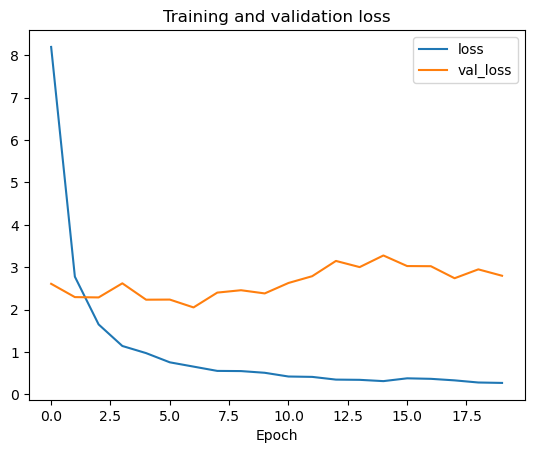

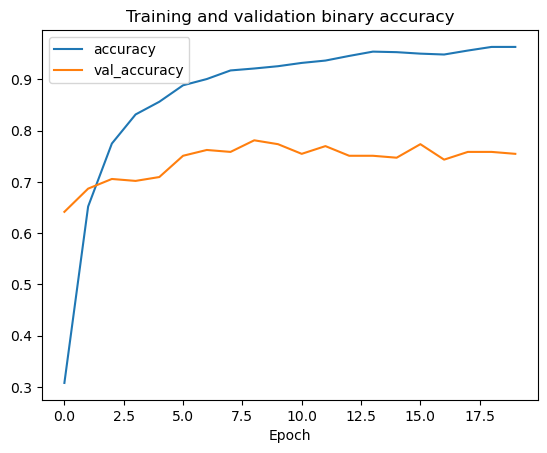

In [41]:
plot_learning(Resnoaugment_History, title = "Training and validation loss", label = "", metric = "loss", val_metric= "val_loss")
plot_learning(Resnoaugment_History, title = "Training and validation binary accuracy", label = "", metric = "accuracy", val_metric= "val_accuracy")

In [42]:
classify_noaugment.evaluate(test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.7887 - loss: 3.8601


[3.8600964546203613, 0.7886792421340942]

In [43]:
predictions = classify_noaugment.predict(test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step


Get the indicies of the classes with the greatest softmax value

The bottom label is the actual classes and the top label is the predicted classes. As we can see, the predictions are fairly accurate. 

4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 888ms/step


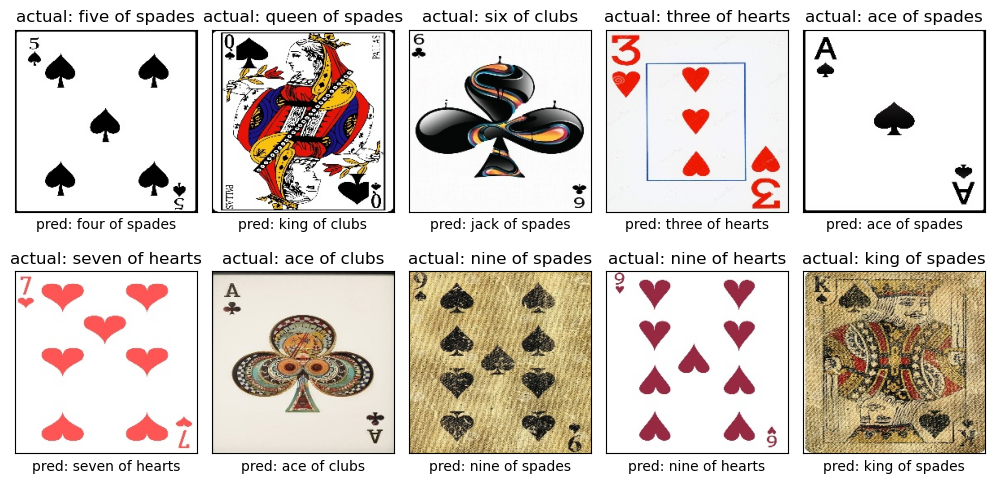

In [56]:
images, labels = next(test)

predictions = classify_noaugment.predict(images)
indices_per_image = np.argmax(predictions, axis=1)

plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    show_img(images[i]/255.0, f"actual: {list(classes.values())[(labels[i] == 1).nonzero()[0].item()]}", f"pred: {list(classes.values())[indices_per_image[i]]}")

plt.tight_layout()

# Image Augmentation

In this section, you are repeating image classification process but with augmented images for training.
Practice at least two image augmentations and see how much they improve the performance of the model.

I am randomly augmenting half of the images by flipping them left or right, adjusting their contrast by a random value between 0.8 and 1.2, and rotating it between -1 and 1. This will allow me to ensure the model doesn't overfit. I decided not to zoom since if I do, I could zoom onto the center of the card when the important part is the outside of the card.

Other than the augmentation, all the model is staying the same since the model performed reasonably well without augmentation.  




In [81]:
data_augmentation = keras.Sequential([
    layers.RandomFlip(mode = "horizontal"),
    layers.RandomRotation(factor = (-.1,.1)),
    layers.RandomContrast(factor=0.2)
])

Visualizing Images with and without augmentation.

Shape of Batch: (128, 224, 224, 3)


<Figure size 1000x1000 with 0 Axes>

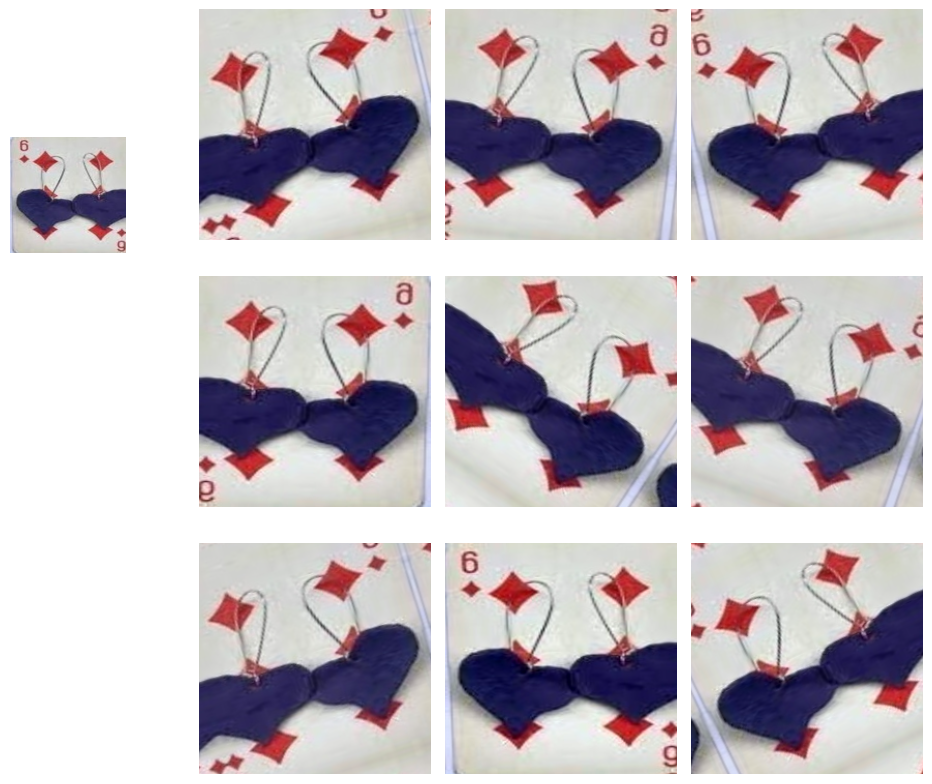

In [82]:
images, labels = next(train)

tf.get_logger().setLevel('ERROR')

plt.figure(figsize=(10, 10))

for i in range(1):
    plt.figure(figsize=(10,8))
    plt.subplot(6, 4, 5)
    plt.imshow(images[0]/255.0)
    plt.axis("off")

    print(f"Shape of Batch: {images.shape}")

    for i in range(9):
        ax = plt.subplot(3, 4, int(i/3)*4 + 2 + (i % 3))

        show_img(data_augmentation(images[0])/255.0, f"")

        plt.tight_layout()
        plt.axis("off")
    plt.tight_layout()

## Method

The augmenting will be done with random flipping and changing the contrast to ensure I don't overfit on the training data. 

In [94]:
def build_model(hp):
    bias = tf.Variable(tf.random.normal([3]), trainable=True, name="bias")

    data_augmentation = keras.Sequential([
    layers.RandomFlip(mode = "horizontal"),
    layers.RandomRotation(factor = (-.1,.1)),
    layers.RandomContrast(factor=0.2)
    ])

    model = keras.Sequential([
                layers.Input(shape=(224,224,3)),
                data_augmentation,
                layers.Lambda(keras.applications.vgg16.preprocess_input),
                layers.Lambda(lambda x: tf.nn.bias_add(x, bias)),
                res_base,
                layers.Flatten(),
                layers.Dense(hp.Choice('units', [100, 265, 300])),
                layers.Dropout(hp.Choice('rate', [0.2, 0.5, 0.6])),
                layers.Dense(53, activation="softmax"),
            ])
    hp_learning_rate = hp.Choice('learning_rate', values=[1e-3, 1e-4, 1e-5])

              
    model.compile(optimizer=keras.optimizers.Adam(learning_rate = hp_learning_rate),
                  loss = "categorical_crossentropy", 
                  metrics = ["accuracy"])
    return model

In [96]:
tuner = keras_tuner.RandomSearch(
    build_model,
    objective=['val_accuracy'],
    directory="tuner_results",
    project_name="classify_aug",
    max_trials=5)

tuner.search(train, epochs=10, validation_data=val)

classify_augment = tuner.get_best_models()[0]

Trial 5 Complete [00h 37m 07s]
multi_objective: -0.7094339728355408

Best multi_objective So Far: -0.7094339728355408
Total elapsed time: 03h 25m 35s


c:\Users\brean\miniconda3\envs\deeplearning\Lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [ ]:
trials = tuner.oracle.trials.values()
accuracies = {i: list(trials)[i].metrics.get_history("val_accuracy")[-1].value[0] for i in range(len(list(trials))) if i != 3}


accuracies

If I am rerunning the code I don't want to run all the trials again.

In [104]:
tuner = keras_tuner.RandomSearch(
    build_model,
    objective=['val_accuracy'],
    directory="tuner_results",
    project_name="classify_aug",
    max_trials=5,
    overwrite=False)

Reloading Tuner from tuner_results\classify_aug\tuner0.json


In [105]:
print(f"Best number of units: {tuner.get_best_hyperparameters()[0].get('units')}")
print(f"Best dropout rate: {tuner.get_best_hyperparameters()[0].get('rate')}")
print(f"Best learning rate: {tuner.get_best_hyperparameters()[0].get('learning_rate')}")

Best number of units: 265
Best dropout rate: 0.5
Best learning rate: 0.001


## Experiments

In [106]:
Resaugment_History = classify_augment.fit(train, epochs = 20,
                verbose = 1, validation_data=val)

Epoch 1/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 229s 4s/step - accuracy: 0.7067 - loss: 18.5533 - val_accuracy: 0.6491 - val_loss: 24.2036
Epoch 2/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 218s 4s/step - accuracy: 0.7408 - loss: 16.3482 - val_accuracy: 0.6377 - val_loss: 26.0194
Epoch 3/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 220s 4s/step - accuracy: 0.7573 - loss: 15.2405 - val_accuracy: 0.6943 - val_loss: 21.9029
Epoch 4/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 219s 4s/step - accuracy: 0.7714 - loss: 14.0469 - val_accuracy: 0.6943 - val_loss: 21.7930
Epoch 5/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 218s 4s/step - accuracy: 0.7878 - loss: 12.5381 - val_accuracy: 0.6830 - val_loss: 22.1799
Epoch 6/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 222s 4s/step - accuracy: 0.7911 - loss: 12.4593 - val_accuracy: 0.6755 - val_loss: 22.9357
Epoch 7/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 219s 4s/step - accuracy: 0.8149 - loss: 10.6431 - val_accuracy: 0.6906 - val_loss: 20.6202
Epoch 8/20
60/60 ━━━━━━━━━━━━━━━━━━━━ 221s 4s/step - accuracy: 0.8245 - loss: 9.3828 - val_accura

In [108]:
classify_augment.save_weights("classify_augment.weights.h5")

I can see that although the training and validation loss trends down, it doesn't change by much. The maximum is around 0.23 and it goes down to approximately 0.22. Similarly, the training and validation binary accuracy goes from approximately 0.92 to 0.93.

Despite this, the loss was already low and the binary accuracy was already high. 

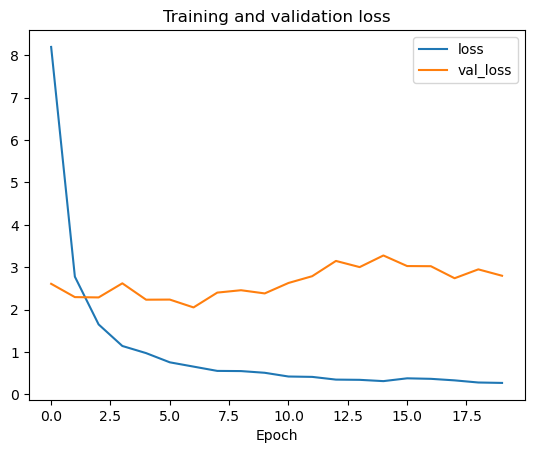

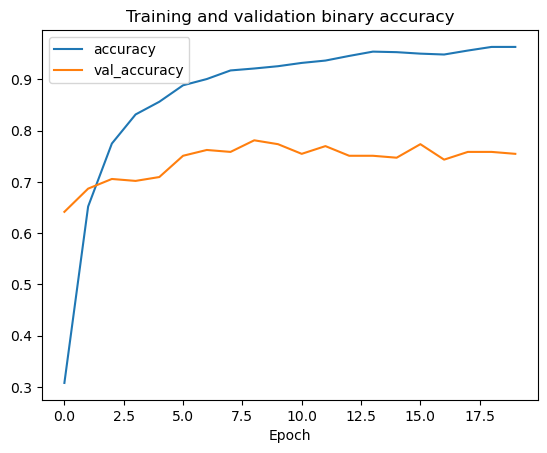

In [ ]:
plot_learning(Resaugment_History, title = "Training and validation loss", label = "", metric = "loss", val_metric= "val_loss")
plot_learning(Resaugment_History, title = "Training and validation binary accuracy", label = "", metric = "accuracy", val_metric= "val_accuracy")

In [ ]:
classify_augment.evaluate(test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.7887 - loss: 3.8601


[3.8600964546203613, 0.7886792421340942]

In [ ]:
predictions = classify_augment.predict(test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step


Get the indicies of the classes with the greatest softmax value

The bottom label is the actual classes and the top label is the predicted classes. As we can see, the predictions are fairly accurate however the prediction accuracy didn't improve after adding augmentation. 

4/4 ━━━━━━━━━━━━━━━━━━━━ 4s 888ms/step


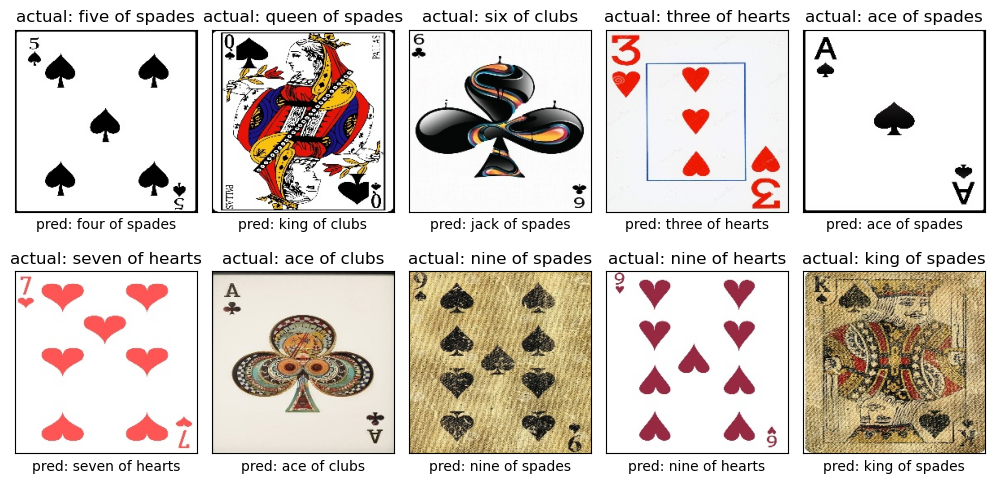

In [ ]:
images, labels = next(test)

predictions = classify_augment.predict(images)
indices_per_image = np.argmax(predictions, axis=1)

plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    show_img(images[i]/255.0, f"actual: {list(classes.values())[(labels[i] == 1).nonzero()[0].item()]}", f"pred: {list(classes.values())[indices_per_image[i]]}")

plt.tight_layout()

# Image Segmentation

Reviewing the lab practice, create a ResNet-50 based image segmentation model.

For this part I am using the carvana dataset. The goal is to be able to separate the image from the background. Since the testing dataset is unlabeled, I cannot compare the predictions to the ground truth labels. Therefore, I am going to split the train dataset into a train, validation, and test split. 


The original image size is 1918 x 1280 but I will downsample to 224x224



In [172]:
def parse_image(img_path, mask_path):

    # image
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (224,224))
    img = img / 255.0

    # mask (GIF)
    mask = tf.io.read_file(mask_path)
    mask = tf.image.decode_gif(mask)   # shape: (frames, H, W, C)
    mask = mask[0]                     # take first frame
    mask = tf.image.resize(mask, (224,224), method="nearest")

    return img, mask

I only have one folder of 5088 images with masks. I am going to do a 80/10/10 train/test/validation split.

Since each car has 16 images from multiple angles, I need to ensure all the images of the same cars are in the training dataset. 

- unique cars in train dataset = int((5088*.8)/16) = 254<br>
- number of images in train dataset = 254 * 16 = 4064<br>
- number of images in test dataset = number of images in validation dataset = (5088 - 4064)/2




In [ ]:
masks = glob.glob("./carvana-image-masking-challenge/train_masks/*")
images = glob.glob("./carvana-image-masking-challenge/train/*")

## 4064 images
train_image_dir = images[0:4064]
train_mask_dir = masks[0:4064]
## 512 images
valid_image_dir = images[4064:4064+(512)]
valid_mask_dir = masks[4064:4064+(512)]
## 512 images
test_image_dir = masks[4064+(512): 4064+(512*2)]
test_mask_dir = masks[4064+(512): 4064+(512*2)]



In [167]:
train_images = []
train_masks = []
valid_images = []
valid_masks = []
test_images = []
test_masks = []
for i in range(len(train_image_dir)):
    image, mask = parse_image(img_path=train_image_dir[i], mask_path=train_mask_dir[i])
    train_images.append(image)
    train_masks.append(mask)

for i in range(len(valid_image_dir)):
    ## validation images
    valid_image, valid_mask = parse_image(img_path=valid_image_dir[i], mask_path=valid_mask_dir[i])
    valid_images.append(valid_image)
    valid_masks.append(valid_mask)
    ## test images
    test_image, test_mask = parse_image(img_path=test_image_dir[i], mask_path=test_mask_dir[i])
    test_images.append(test_image)
    test_masks.append(test_mask)

In [168]:
train_images = np.array(train_images)
train_masks = np.array(train_masks)

valid_images = np.array(valid_images)
valid_masks = np.array(valid_masks)

test_images = np.array(test_images)
test_masks = np.array(test_masks)

In [170]:
def display(display_list: list): ## bot is bottom
    plt.figure(figsize = (15,15))
    title = ["Input Image", "True Mask", "Predicted Mask"]
    for i in range(len(display_list)):
        plt.subplot(1,len(display_list),i+1)
        plt.title(title[i])
        plt.imshow(tf.keras.utils.array_to_img(display_list[i]))
        plt.axis("off")

    plt.show()

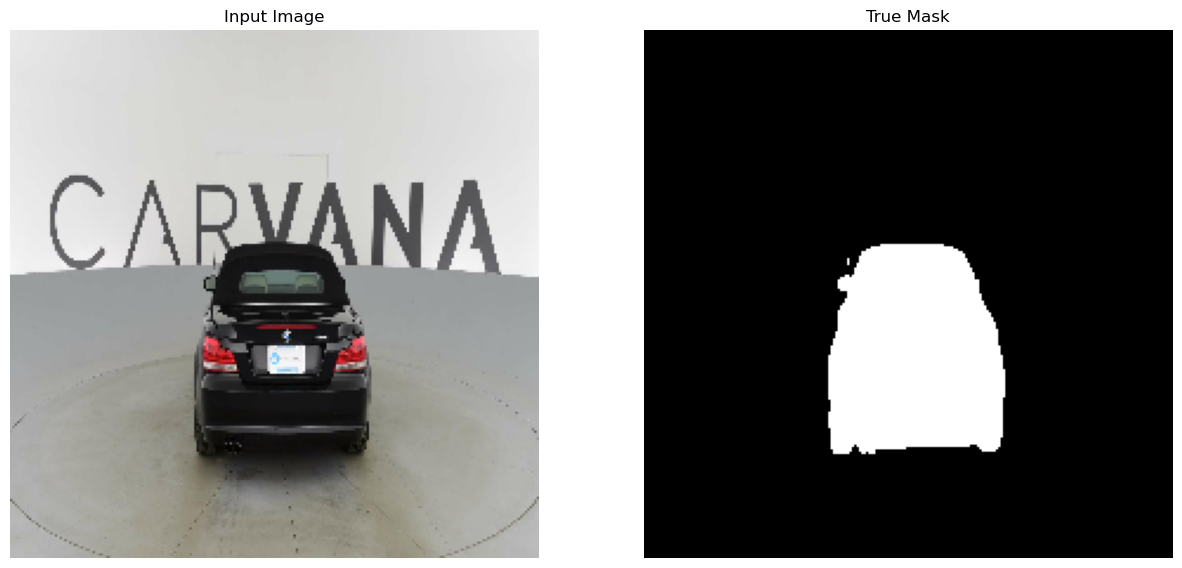

In [171]:
random_index = np.random.choice(train_images.shape[0])
sample_image, sample_mask = train_images[random_index], train_masks[random_index]
display([sample_image, sample_mask])

## Method

I am using resnet50 within UNet. The Resnnet model be the encoder part which will perform the feature extraction and the UNet be the decoder which will do the upsampling and wil connect the encoder and decoder with skip connections. 

In [ ]:
unet_segmentation_model = sm.Unet('resnet50', 
                encoder_weights='imagenet',
                classes=1,                 # background vs foreground
                activation='softmax',
                input_shape=(224,224,3),
                include_top=False) 




In [ ]:
## maybe x = image y = mask ????

unet_segmentation_History = unet_segmentation_model.fit(x = train_images, y = train_masks, 
                    epochs = 20, steps_per_epoch=57, validation_data=(valid_images, valid_masks))

## Experiments

# Conclusions

Discuss the challenges or somethat that you learned.
If you have any suggestion about the assignment, you can write about it.

# References

List your references to complete your assignment. Use a proper reference style (APA, MLA, etc.).

## Grading

As of size of images, please do not submit your data. Instead, provide instructions to download them along with the link. Your notebook is supposed to run well after downloading to the working directory.

**Note: this is a WRITING assignment. Proper writing is REQUIRED. Comments are not considered as writing.**


Points | | Description
--|--|:--
5 | Introduction  
10 | Data |
 | 5| description
 | 5| plots for understanding or analysis
30 | Image Classification |
 | 10| Explanation of deep network architecture and implementation
 | 5|  Hyperparameter search
 | 10| Visualization, evaluation of results
 | 5 | Analysis and discussion
15 | Image Augmentation |
 | 5| Explanation of deep network architecture and implementation
 | 5| Visualization, evaluation of results
 | 5 | Analysis and discussion
30 | Image Segmentation |
 | 10| Explanation of deep network architecture and implementation
 | 5|  Hyperparameter search
 | 10| Visualization, evaluation of results
 | 5 | Analysis and discussion
5 | Conclusions
5 | References